# 실습 6-1 : Clustering (K-Means, DBSCAN)

#### **<실습 내용>**

1. K-Means, DBSCAN 이해하기

2. Clustering 기반 RCA
- 반도체 공정 데이터 적용
- 연속형 변수 기반 클러스터링 (K-Means, DBSCAN)
- 연속형 + 범주형 기반 클러스터링 (K-Means, DBSCAN)

3. Vibe Coding 실습
- 통신사 고객 이탈 데이터 활용

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.datasets import make_blobs, make_moons  # 개념 설명용 가상 데이터 생성 함수

from sklearn.preprocessing import StandardScaler  # 변수 스케일링 (거리 기반 알고리즘엔 필수)
from sklearn.cluster import KMeans, DBSCAN        # 군집화 알고리즘 2종
from sklearn.metrics import silhouette_score       # 군집이 잘 나뉘었는지 점수로 평가하는 지표
from collections import Counter

---

## 1) K-Means, DBSCAN 이해하기

### 1-1) 가상 데이터 만들기

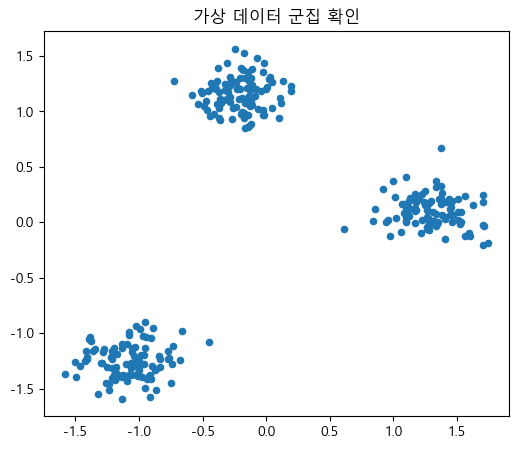

In [2]:
# make_blobs: 3개의 중심을 기준으로 뭉쳐진 가상 데이터 300개를 생성
# 군집이 몇 개인지 이미 아는 상태에서 알고맂므이 3개 군집을 잘 찾아내는지 확인하기 위함

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.title("가상 데이터 군집 확인")
plt.show()

### 1-2) K-Means

> **K-Means**는 K개 군집의 중심(Centroid)을 반복적으로 갱신하여 데이터를 가장 가까운 군집에 배정하는 알고리즘임
> 1. 초기 K개의 중심을 선정 (기본값: `init='k-means++'`, 서로 멀리 떨어진 점들을 초기 중심으로 골라 랜덤 초기화보다 안정적인 결과를 줌)
> 2. 각 데이터를 가장 가까운 중심에 배정
> 3. 각 군집의 중심을 재계산
> 4. 중심이 변하지 않을 때까지 2-3 반복

In [3]:
# 1) 기본 K-Means: K를 임의로 3으로 지정하고 학습
# n_clusters: 생성할 군집수
# n_init: 초기 중심점을 몇 번 다르게 랜덤 배치해서 시도할지 
#         (10이면 10번 시도 후 가장 좋은 결과 채택)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# 데이터별 군집 학습 및 군집 번호 예측
cluster = kmeans.fit_predict(X)
cluster

array([1, 1, 2, 0, 1, 3, 2, 3, 2, 2, 2, 3, 2, 2, 1, 2, 1, 0, 2, 2, 2, 2,
       3, 1, 2, 4, 1, 0, 3, 2, 2, 2, 4, 2, 1, 2, 4, 3, 1, 3, 3, 2, 1, 0,
       2, 2, 4, 0, 4, 3, 3, 4, 4, 2, 4, 3, 4, 2, 3, 2, 4, 3, 3, 4, 1, 0,
       0, 4, 1, 2, 3, 4, 1, 2, 2, 4, 1, 0, 2, 3, 2, 2, 4, 2, 3, 4, 4, 2,
       3, 2, 1, 2, 4, 2, 2, 1, 1, 2, 1, 4, 0, 2, 0, 2, 2, 2, 2, 2, 3, 1,
       3, 2, 2, 2, 2, 3, 1, 0, 1, 0, 3, 3, 2, 4, 4, 1, 4, 2, 4, 1, 2, 2,
       2, 2, 2, 3, 0, 1, 2, 1, 2, 2, 4, 2, 0, 0, 3, 2, 3, 2, 2, 4, 3, 1,
       2, 0, 3, 1, 4, 2, 2, 1, 4, 4, 2, 4, 0, 2, 2, 2, 2, 2, 0, 2, 0, 3,
       3, 2, 3, 3, 4, 2, 1, 3, 3, 1, 3, 2, 0, 0, 4, 4, 0, 1, 0, 0, 3, 3,
       2, 4, 2, 2, 0, 0, 2, 3, 1, 1, 3, 2, 2, 1, 3, 0, 4, 4, 4, 4, 2, 1,
       4, 0, 1, 1, 2, 0, 1, 4, 0, 2, 2, 4, 2, 1, 3, 3, 1, 3, 4, 1, 4, 3,
       3, 2, 4, 0, 3, 3, 4, 3, 4, 0, 1, 3, 3, 4, 0, 2, 1, 2, 2, 2, 4, 2,
       3, 0, 4, 3, 3, 2, 2, 3, 0, 3, 4, 4, 1, 2, 2, 2, 0, 3, 3, 0, 4, 3,
       4, 3, 0, 4, 2, 0, 3, 2, 1, 2, 0, 2, 4, 4], d

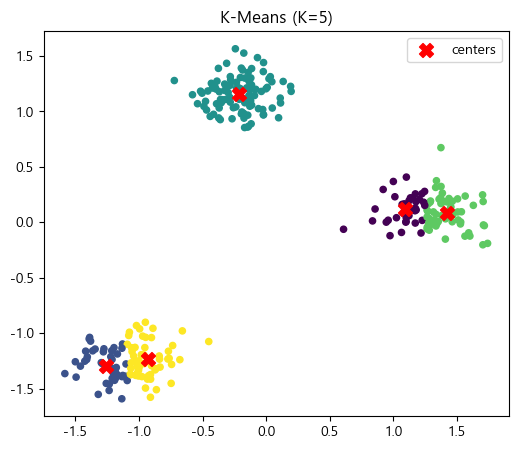

In [4]:
plt.figure(figsize=(6, 5))  

# c: 각 점의 색상을 지정하는 값 (여기선 군집 번호로 색 구분)
# labels_: 각 데이터가 어느 군집에 배정됐는지 (fit_predict 결과와 동일)
# s: 점 크기
# cmap: 색상 팔레트 (viridis는 연속형 색상 매핑)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')

# cluster_centers_: 학습된 각 군집의 중심 좌표
# c='red': 중심점 색상 고정
# marker='X': 점 모양을 X자로 표시 
# s=200: 중심점은 크게 표시해서 눈에 띄게 함
# label='centers': 범례(legend)에 표시될 이름

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=100, label='centers')

plt.title("K-Means (K=5)")  
plt.legend()  
plt.show()

#### K 값에 따른 결과 비교

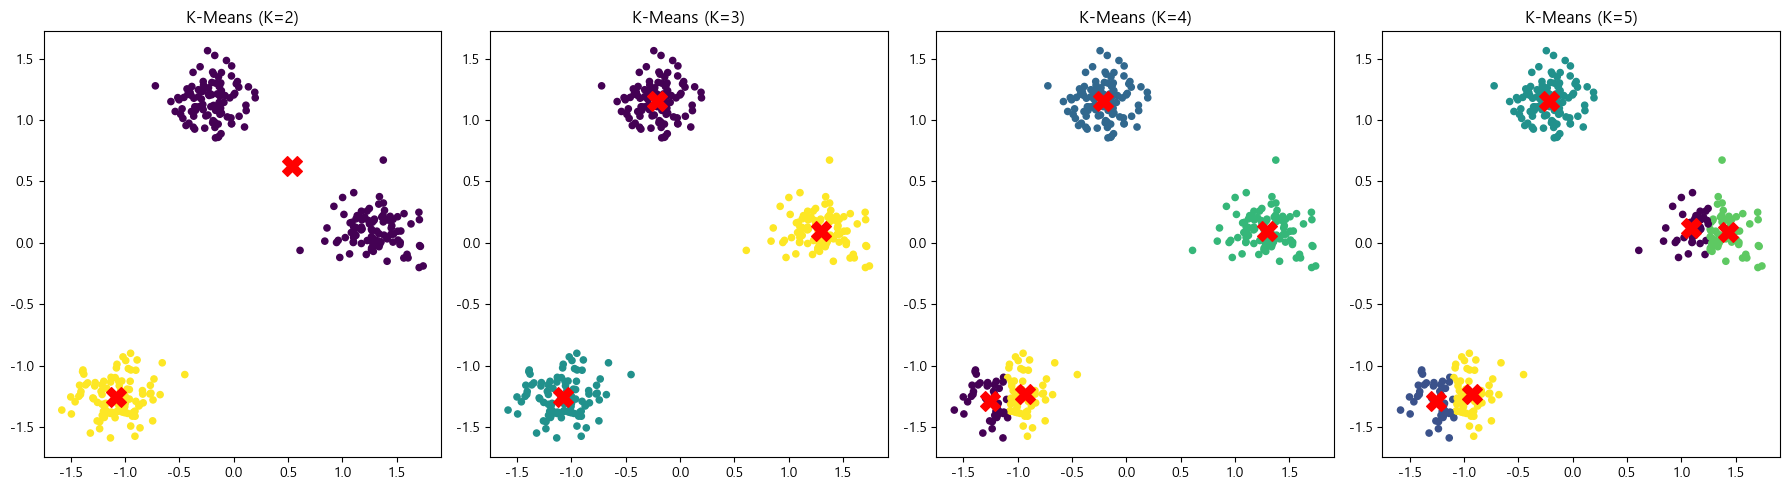

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, k in zip(axes, [2, 3, 4, 5]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')  # labels_: 각 데이터가 배정된 군집 번호
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)  # cluster_centers_: 학습된 군집 중심 좌표
    ax.set_title(f"K-Means (K={k})")

plt.tight_layout()
plt.show()

#### Silhouette Method로 최적 K 결정

> **Silhouette Score**는 각 데이터가 자신이 속한 군집과 얼마나 잘 맞는지를 측정함
> - 1에 가까울수록 올바른 군집
> - K를 변화시키며 평균 Silhouette Score가 최대인 K를 선택

In [6]:
sil_scores = []
K_range = range(2, 10)  # K를 2~9까지 바꿔가며 비교

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit_predict(X)
    # silhouette_score: 군집이 얼마나 잘 나뉘었는지를 -1~1 사이 숫자로 요약
    # 1에 가까울수록 좋음
    sil_scores.append(silhouette_score(X, kmeans.labels_))

best_k = K_range[np.argmax(sil_scores)]  # 점수가 가장 높은 K를 최적 K로 선택
print(f"최적 K: {best_k} (Silhouette Score: {max(sil_scores):.3f})")

최적 K: 3 (Silhouette Score: 0.848)


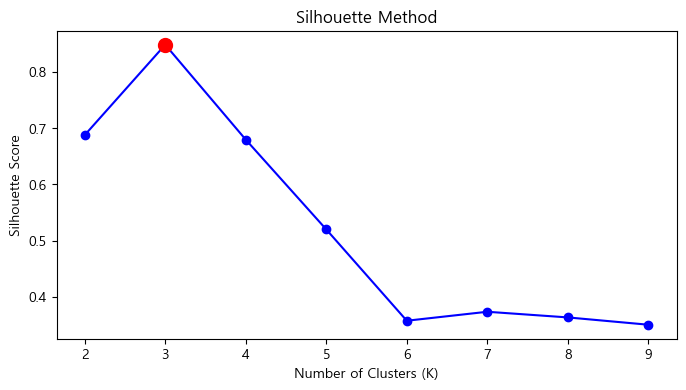

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')  # K별 실루엣 점수 선 그래프

# best_k 지점만 빨간 점으로 강조 표시
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)

plt.xlabel("Number of Clusters (K)")    # x축 라벨: K 값
plt.ylabel("Silhouette Score")          # y축 라벨: 실루엣 점수 (1에 가까울수록 군집 잘 나뉨)
plt.title("Silhouette Method")         
plt.xticks(K_range)                  
plt.show()

---

### 1-3) DBSCAN

> **DBSCAN**은 밀도 기반 클러스터링으로 데이터가 많이 모여 있는 영역을 하나의 군집으로 인식하는 방법임 (군집 수를 미리 지정할 필요가 없음)
>
> - **eps**: 이웃으로 인정할 최대 거리
> - **min_samples**: 하나의 군집으로 인정하기 위한 최소 이웃 수
> - **Core Point**: 주변에 이웃이 충분히 많은 중심 데이터
> - **Border Point**: 군집 가장자리에 위치한 데이터
> - **Noise Point**: 어떤 군집에도 속하지 않는 이상치 데이터 (label = -1)
>
> DBSCAN은 이상 탐지에도 유용함

In [8]:
# eps: 이웃으로 인정할 최대 거리 (이 반경 안에 점이 몰려있으면 같은 군집)
# min_samples: 하나의 군집으로 인정하기 위한 최소 이웃 수
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 데이터별 군집 학습 및 군집 번호 예측
# DBSCAN은 K-Means와 달리 노이즈(어느 군집에도 속하지 않는 점)를 -1로 표시
cluster = dbscan.fit_predict(X)
cluster

array([0, 0, 1, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 1, 1, 1, 1,
       2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 2, 1, 0, 2,
       1, 1, 0, 2, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2,
       2, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1,
       2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0,
       2, 1, 1, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 1, 0, 2, 0,
       1, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2,
       1, 0, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 1, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2,
       2, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1, 0, 1, 1, 1, 0, 1,
       2, 2, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0])

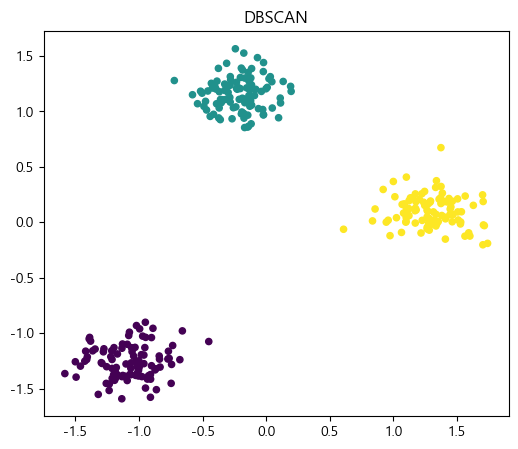

In [9]:
plt.figure(figsize=(6, 5))

# c: 군집 번호로 색 구분 (-1은 노이즈, 보통 다른 색으로 튐)
plt.scatter(X[:, 0], X[:, 1], c=cluster, s=20, cmap='viridis')
plt.title("DBSCAN")
plt.show()

#### eps 값에 따른 결과 비교

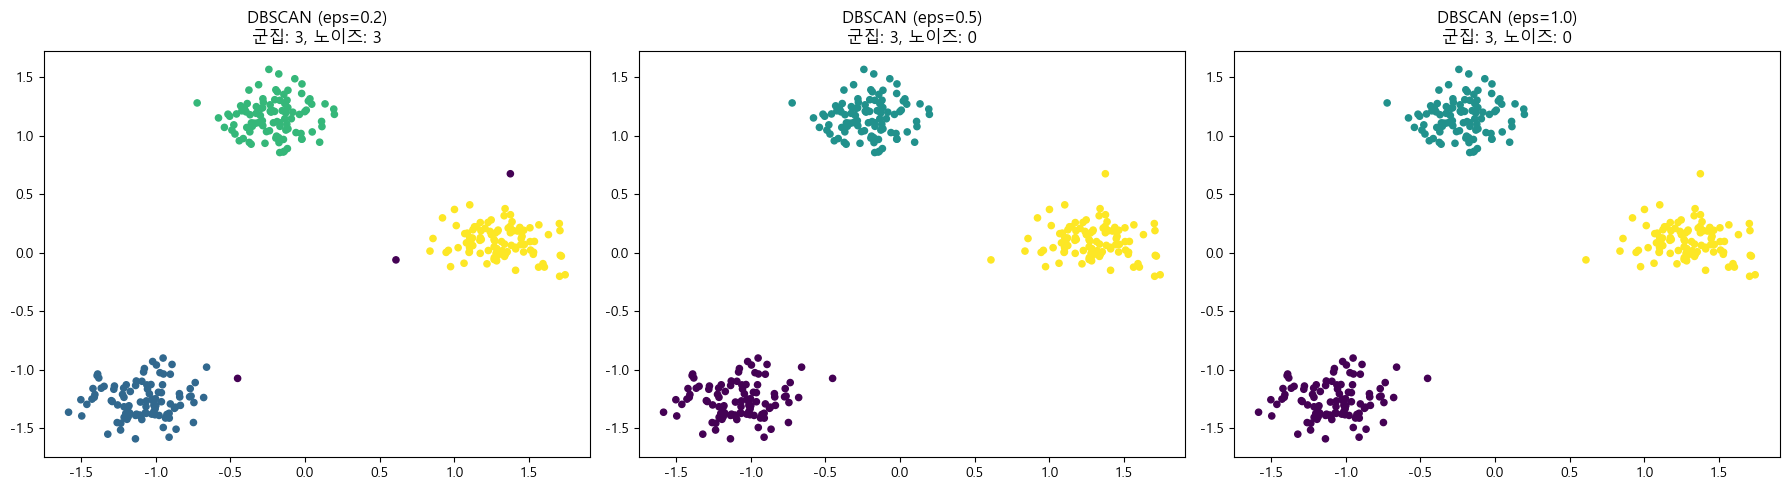

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, [0.2, 0.5, 1.0]):
    # eps: 이웃으로 인정할 반경 / min_samples: Core Point가 되기 위한 최소 이웃 수
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)  # 라벨 -1(노이즈)은 군집 수에서 제외하고 계산
    n_noise = list(dbscan.labels_).count(-1)  # 어떤 군집에도 속하지 못한 노이즈 데이터 개수

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

#### K-distance Plot으로 최적 eps 결정

> **eps** : 두 데이터를 이웃으로 판단하기 위한 최대 거리

- **K-distance Plot**
  - 각 데이터의 K번째 최근접 이웃까지의 거리를 계산한 후, 이를 오름차순으로 정렬하여 나타낸 그래프

- **eps 선택 방법**
  - 그래프에서 거리가 급격히 증가하기 시작하는 지점(Elbow Point)의 거리 값을 eps로 선택

- **해석**
  - 그래프가 완만한 구간 → 군집 내부 데이터
  - 그래프가 급격히 상승하는 구간 → 이상치(Noise) 후보
  - Elbow Point의 y값 → 적절한 eps 후보

- **의미**
  - Elbow Point 이전의 데이터는 군집에 속할 가능성이 높음
  - Elbow Point 이후의 데이터는 이상치(Noise)일 가능성이 높음

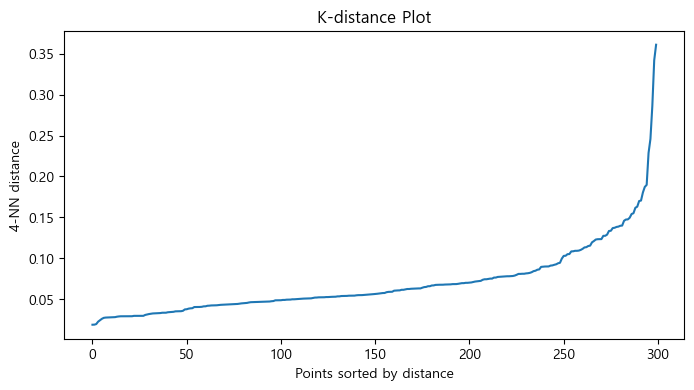

In [11]:
from sklearn.neighbors import NearestNeighbors

# min_samples를 먼저 정해야 k-distance 계산 가능 
# 보통 min_samples = 데이터 차원수*2
# 현재 예시는 2차원이니 min_samples=4~5 근처로 시작

min_samples = 4

# 각 점마다 자신을 포함해 min_samples번째로 가까운 이웃까지의 거리 계산
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# min_samples번째 이웃까지의 거리만 추출 후 오름차순 정렬
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot")
plt.show()

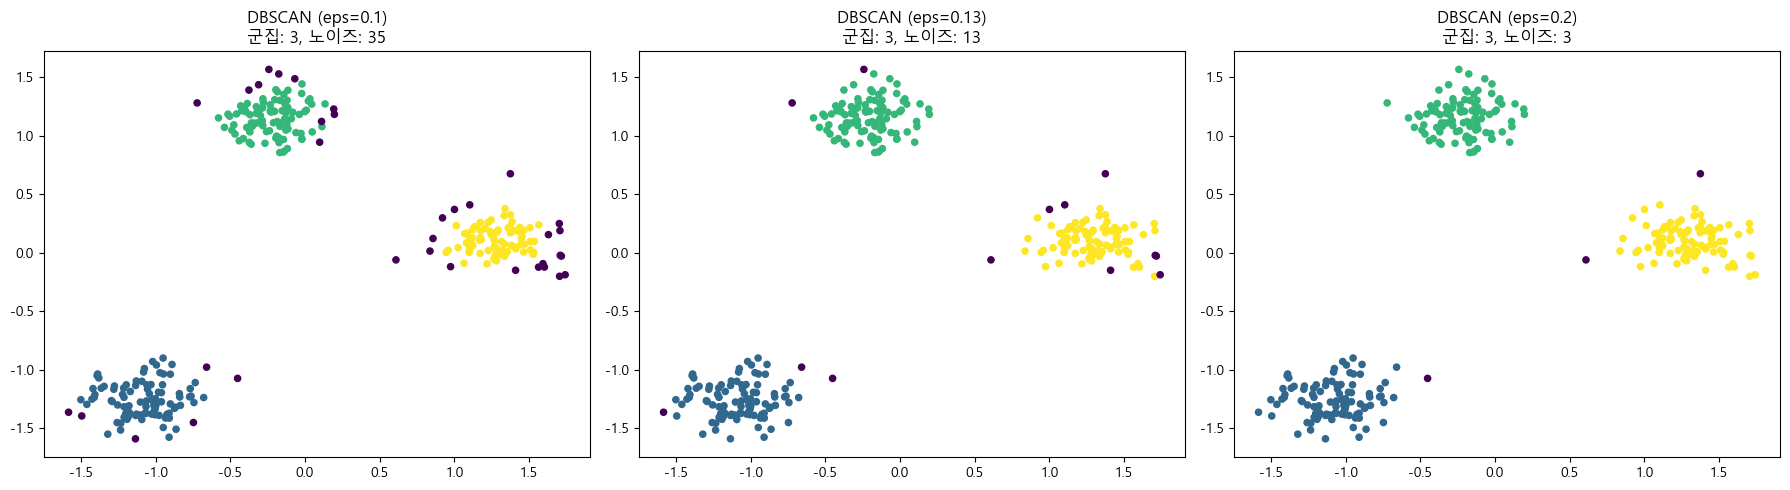

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-distance plot의 기준으로 주변 최적의 eps 후보 비교
for ax, eps in zip(axes, [0.1, 0.13, 0.2]):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
    n_noise = list(dbscan.labels_).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

### 1-4) 비선형 데이터에서 K-Means vs DBSCAN

> DBSCAN은 다양한 모양의 군집을 형성할 수 있어 K-Means가 잘 작동하지 않는 비선형 데이터에서 강점을 보임

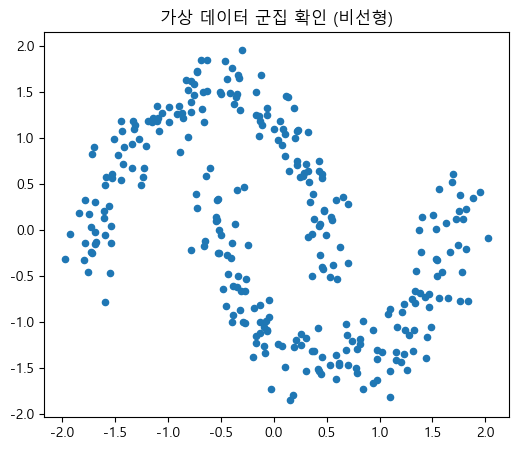

In [13]:
# 1) 가상 데이터 만들기
# make_moons: 초승달 모양 2개가 맞물린 비선형 데이터 
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X_moon = StandardScaler().fit_transform(X_moon)

plt.figure(figsize=(6, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], s=20)
plt.title("가상 데이터 군집 확인 (비선형)")
plt.show()

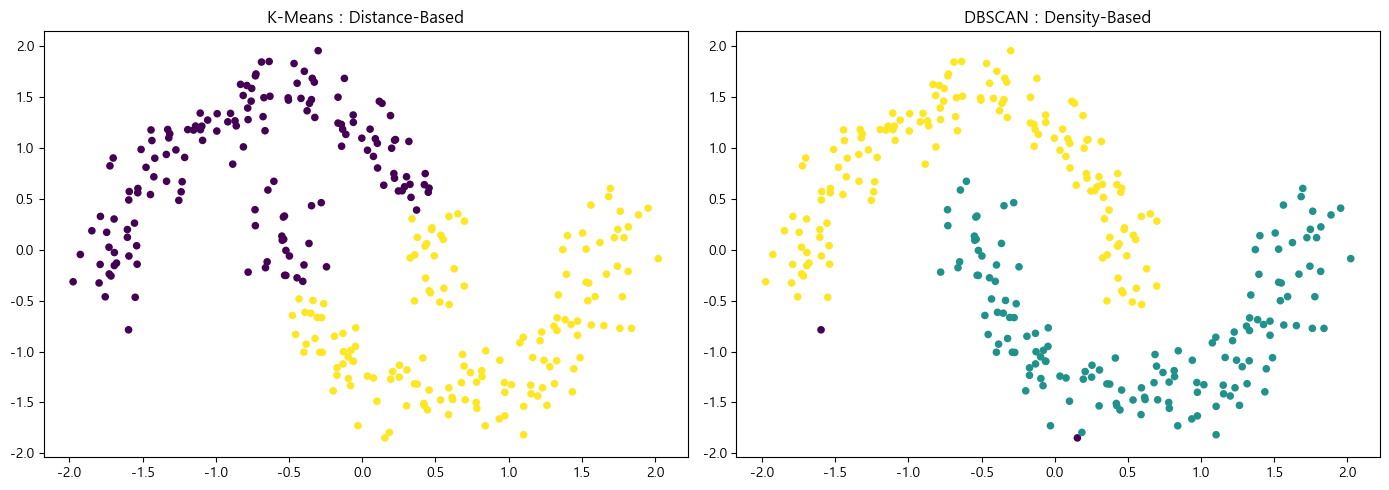

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means: '중심까지의 거리'만 고려함
kmeans_moon = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans_moon.fit_predict(X_moon)
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans_moon.labels_, s=20, cmap='viridis')
axes[0].set_title("K-Means : Distance-Based")

# DBSCAN: '밀도가 이어지는지'로 판단함
dbscan_moon = DBSCAN(eps=0.3, min_samples=5)
dbscan_moon.fit_predict(X_moon)
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=dbscan_moon.labels_, s=20, cmap='viridis')
axes[1].set_title("DBSCAN : Density-Based")

plt.tight_layout()
plt.show()

## 2) Clustering 기반 RCA 수행

**활용할 반도체 공정 데이터 소개**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

In [15]:
data = pd.read_csv("dataset/day6-1_data.csv")

# 조건 기반 타겟변수 생성
data["Fail"] = ["Fault" if y >= 3 else "Pass" for y in data["Y"]]
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 13)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass


In [16]:
print(data["Fail"].value_counts())

Fail
Pass     471
Fault    125
Name: count, dtype: int64


### 2-1) 연속형 변수만 활용한 경우

In [17]:
num_cols = ["C1", "C2"]

# 거리 기반 알고리즘이므로 표준화 필수
X_num = StandardScaler().fit_transform(data[num_cols])

#### K-Menas

> Silhouette 기반 최적 K 찾기

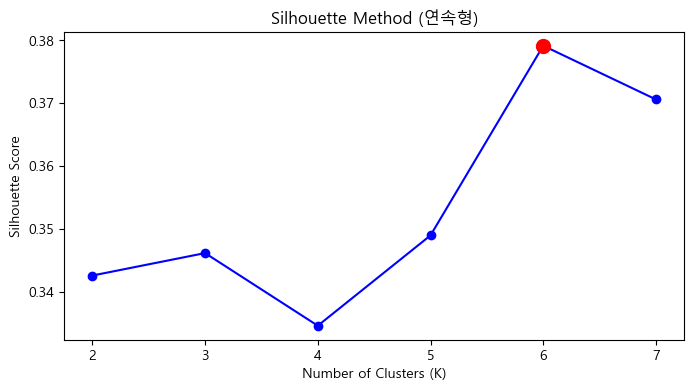

최적 K: 6


In [18]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_num)
    score = silhouette_score(X_num, labels)  # 군집이 잘 나뉠수록 1에 가까움
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]  # 실루엣 점수가 가장 높은 K

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

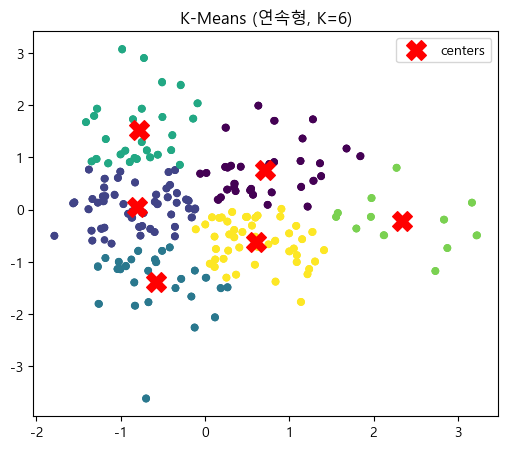

In [19]:
# 최적 K로 최종 K-Means 학습
kmeans_num = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_num"] = kmeans_num.fit_predict(X_num)

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_kmeans_num"], s=20, cmap='viridis')
plt.scatter(kmeans_num.cluster_centers_[:, 0], kmeans_num.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='centers')
plt.title(f"K-Means (연속형, K={best_k})")
plt.legend()
plt.show()

#### DBSCAN

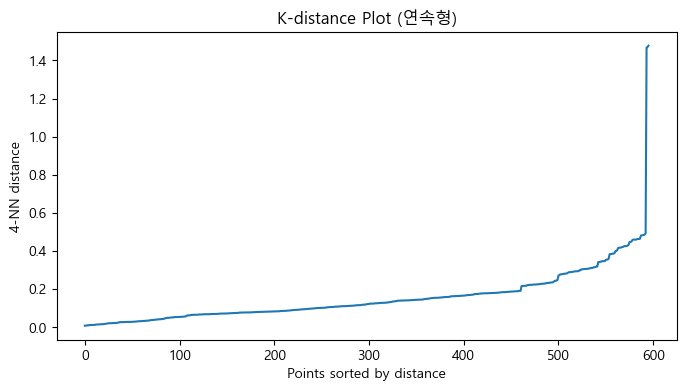

In [20]:
min_samples = 4  # 2차원 데이터 기준 통상 4~5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_num)
distances, indices = neighbors_fit.kneighbors(X_num)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형)")
plt.show()

군집 수: 7, 노이즈: 33


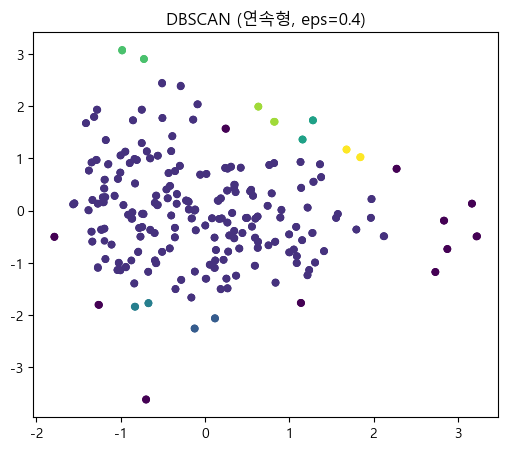

In [21]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_num = 0.4 

dbscan_num = DBSCAN(eps=eps_num, min_samples=min_samples)
data["cluster_dbscan_num"] = dbscan_num.fit_predict(X_num)

n_clusters = len(set(data["cluster_dbscan_num"])) - (1 if -1 in data["cluster_dbscan_num"].values else 0)
n_noise = (data["cluster_dbscan_num"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_dbscan_num"], s=20, cmap='viridis')
plt.title(f"DBSCAN (연속형, eps={eps_num})")
plt.show()

#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형 변수 값 비교

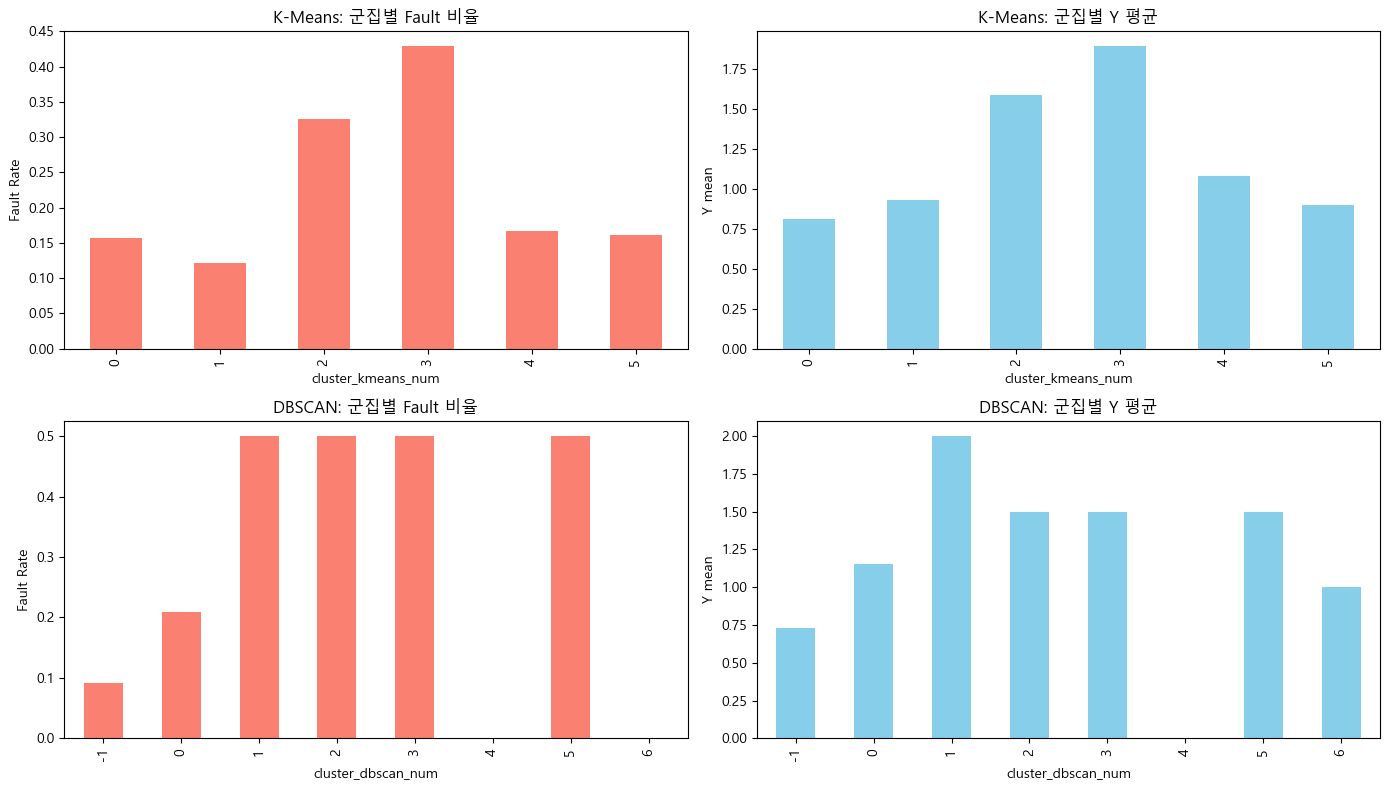

In [22]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# K-Means: 군집별 Fault 비율
kmeans_fault_rate = data.groupby("cluster_kmeans_num")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means: 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

# K-Means: 군집별 Y 평균
data.groupby("cluster_kmeans_num")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means: 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

# DBSCAN: 군집별 Fault 비율
dbscan_fault_rate = data.groupby("cluster_dbscan_num")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN: 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

# DBSCAN: 군집별 Y 평균
data.groupby("cluster_dbscan_num")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN: 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

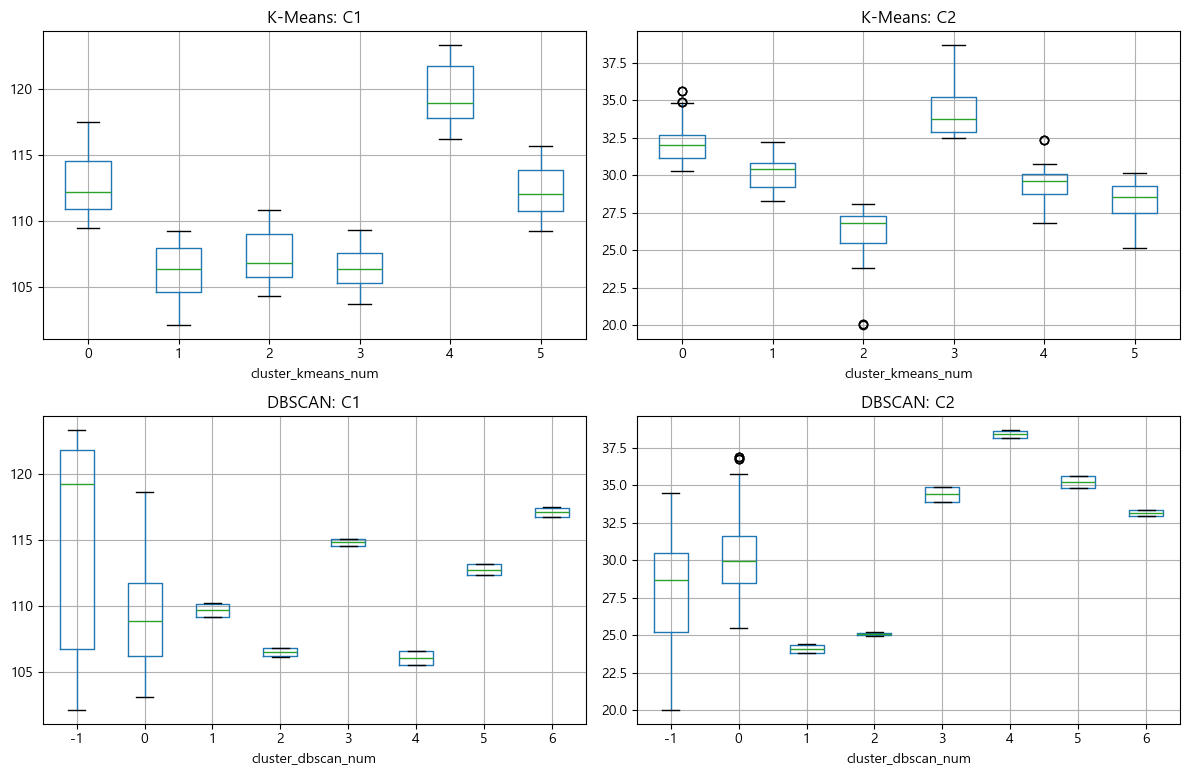

In [23]:
# 2. 군집별 연속형 변수(C1, C2) 값 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data.boxplot(column="C1", by="cluster_kmeans_num", ax=axes[0, 0])
axes[0, 0].set_title("K-Means: C1")

data.boxplot(column="C2", by="cluster_kmeans_num", ax=axes[0, 1])
axes[0, 1].set_title("K-Means: C2")

data.boxplot(column="C1", by="cluster_dbscan_num", ax=axes[1, 0])
axes[1, 0].set_title("DBSCAN: C1")

data.boxplot(column="C2", by="cluster_dbscan_num", ax=axes[1, 1])
axes[1, 1].set_title("DBSCAN: C2")

plt.suptitle("")  # boxplot 자동 상위 제목 제거
plt.tight_layout()
plt.show()

---

### 2-2) 모든 변수를 활용한 경우

In [24]:
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
num_cols = ["C1", "C2"]

# 범주형은 원-핫 인코딩, 연속형은 표준화해서 하나의 행렬로 합침
X_cat = pd.get_dummies(data[cat_cols].astype("object"))
X_cat[num_cols] = StandardScaler().fit_transform(data[num_cols])

#### K-Means

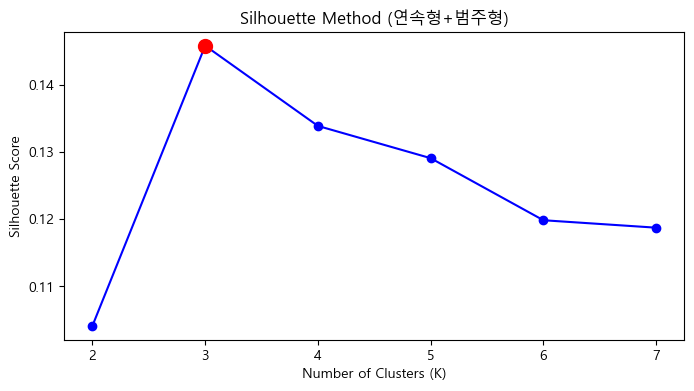

최적 K: 3


In [25]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cat)
    score = silhouette_score(X_cat, labels)
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형+범주형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

In [26]:
kmeans_full = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_full"] = kmeans_full.fit_predict(X_cat)

#### DBSCAN

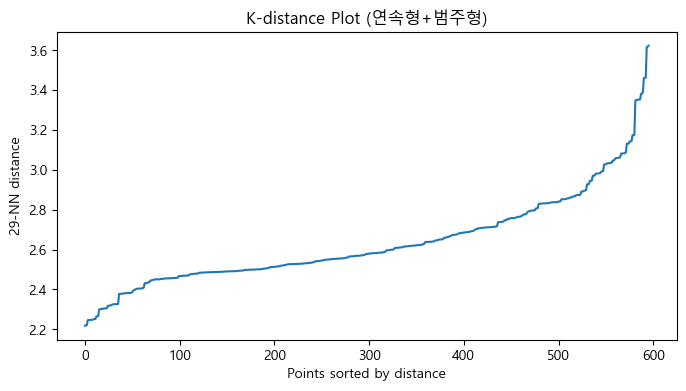

In [27]:
min_samples = X_cat.shape[1] + 1  # 차원이 늘어났으니 min_samples도 늘림

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cat)
distances, indices = neighbors_fit.kneighbors(X_cat)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형+범주형)")
plt.show()

In [28]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_full = 2.7

dbscan_full = DBSCAN(eps=eps_full, min_samples=min_samples)
data["cluster_dbscan_full"] = dbscan_full.fit_predict(X_cat)

n_clusters = len(set(data["cluster_dbscan_full"])) - (1 if -1 in data["cluster_dbscan_full"].values else 0)
n_noise = (data["cluster_dbscan_full"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

군집 수: 1, 노이즈: 24


#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형/범주형 변수 값 비교

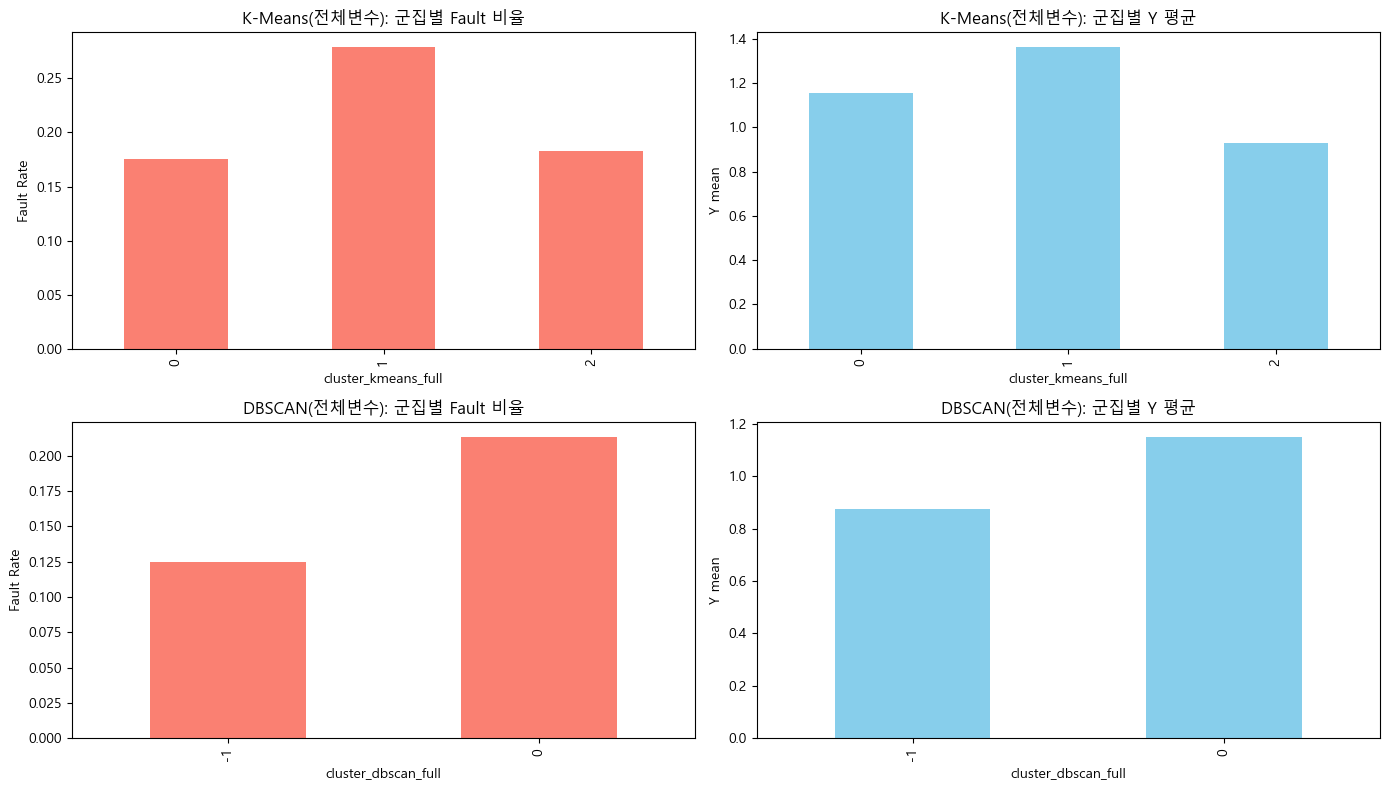

In [29]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

kmeans_fault_rate = data.groupby("cluster_kmeans_full")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means(전체변수): 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

data.groupby("cluster_kmeans_full")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means(전체변수): 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

dbscan_fault_rate = data.groupby("cluster_dbscan_full")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN(전체변수): 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

data.groupby("cluster_dbscan_full")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN(전체변수): 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

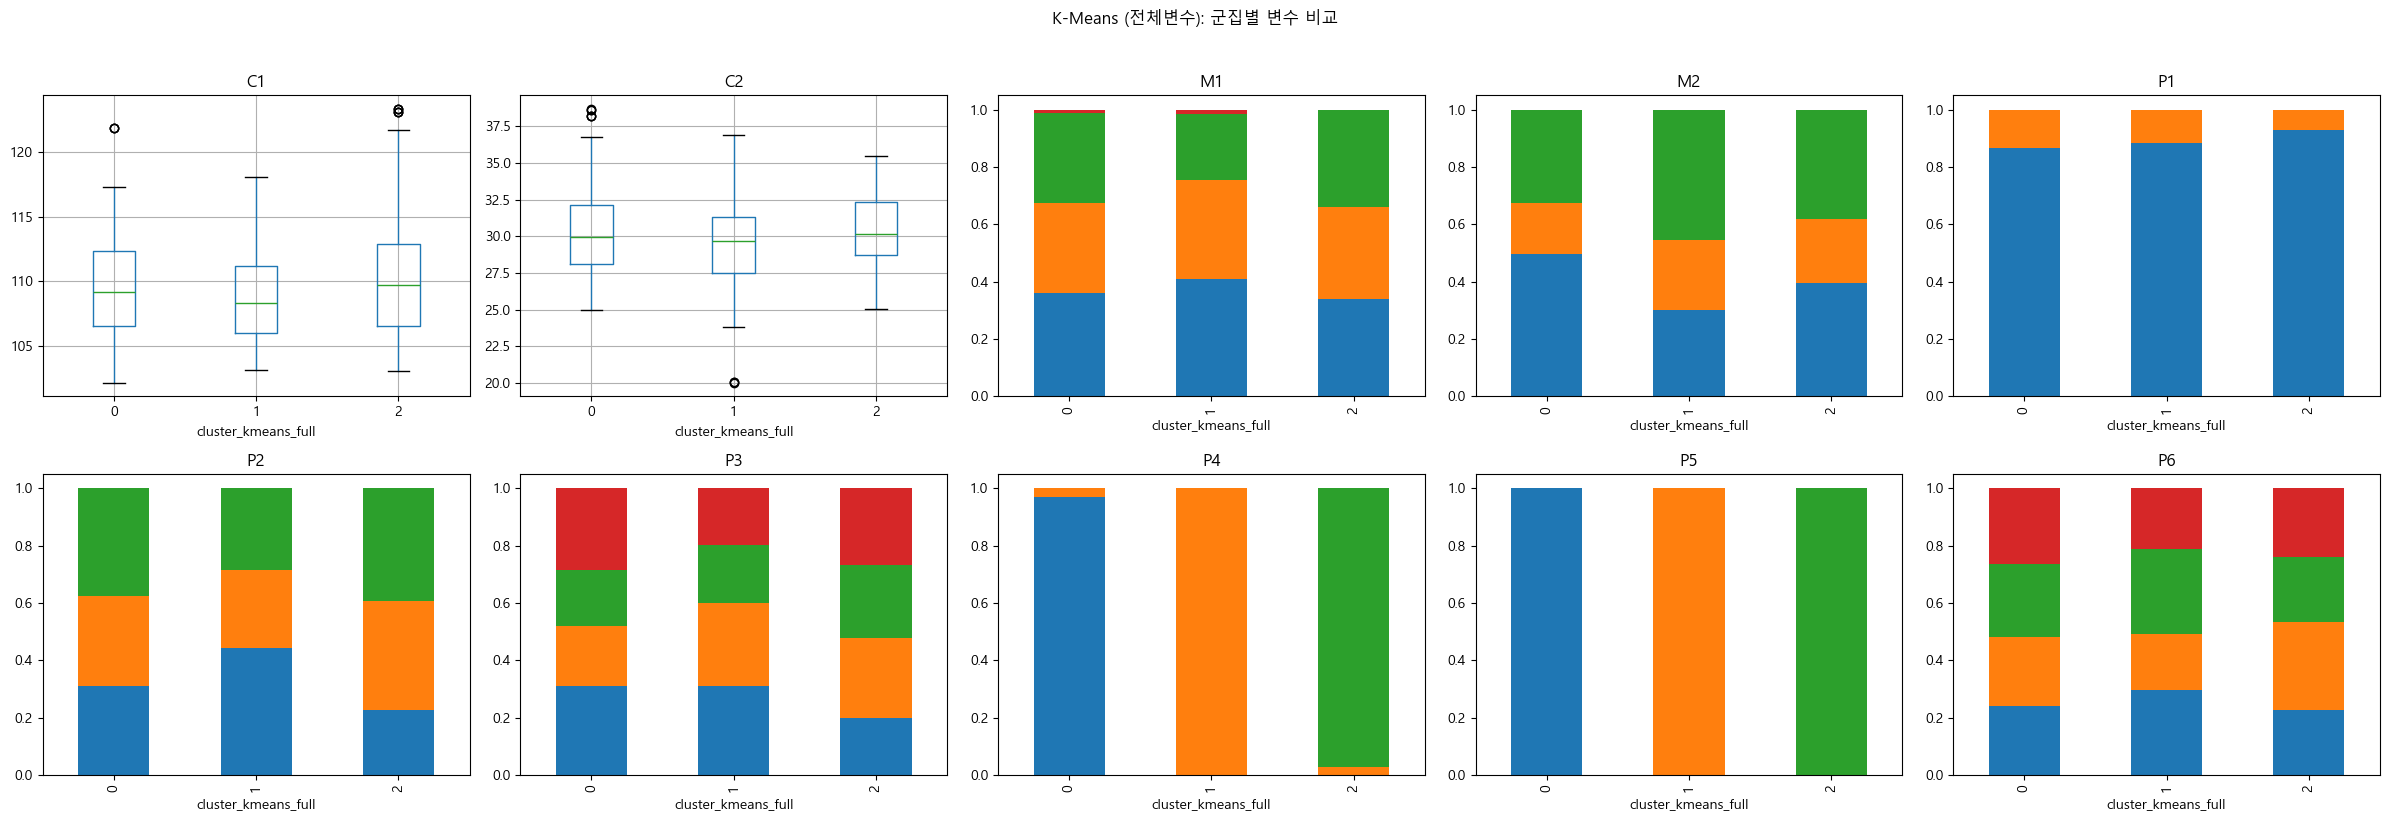

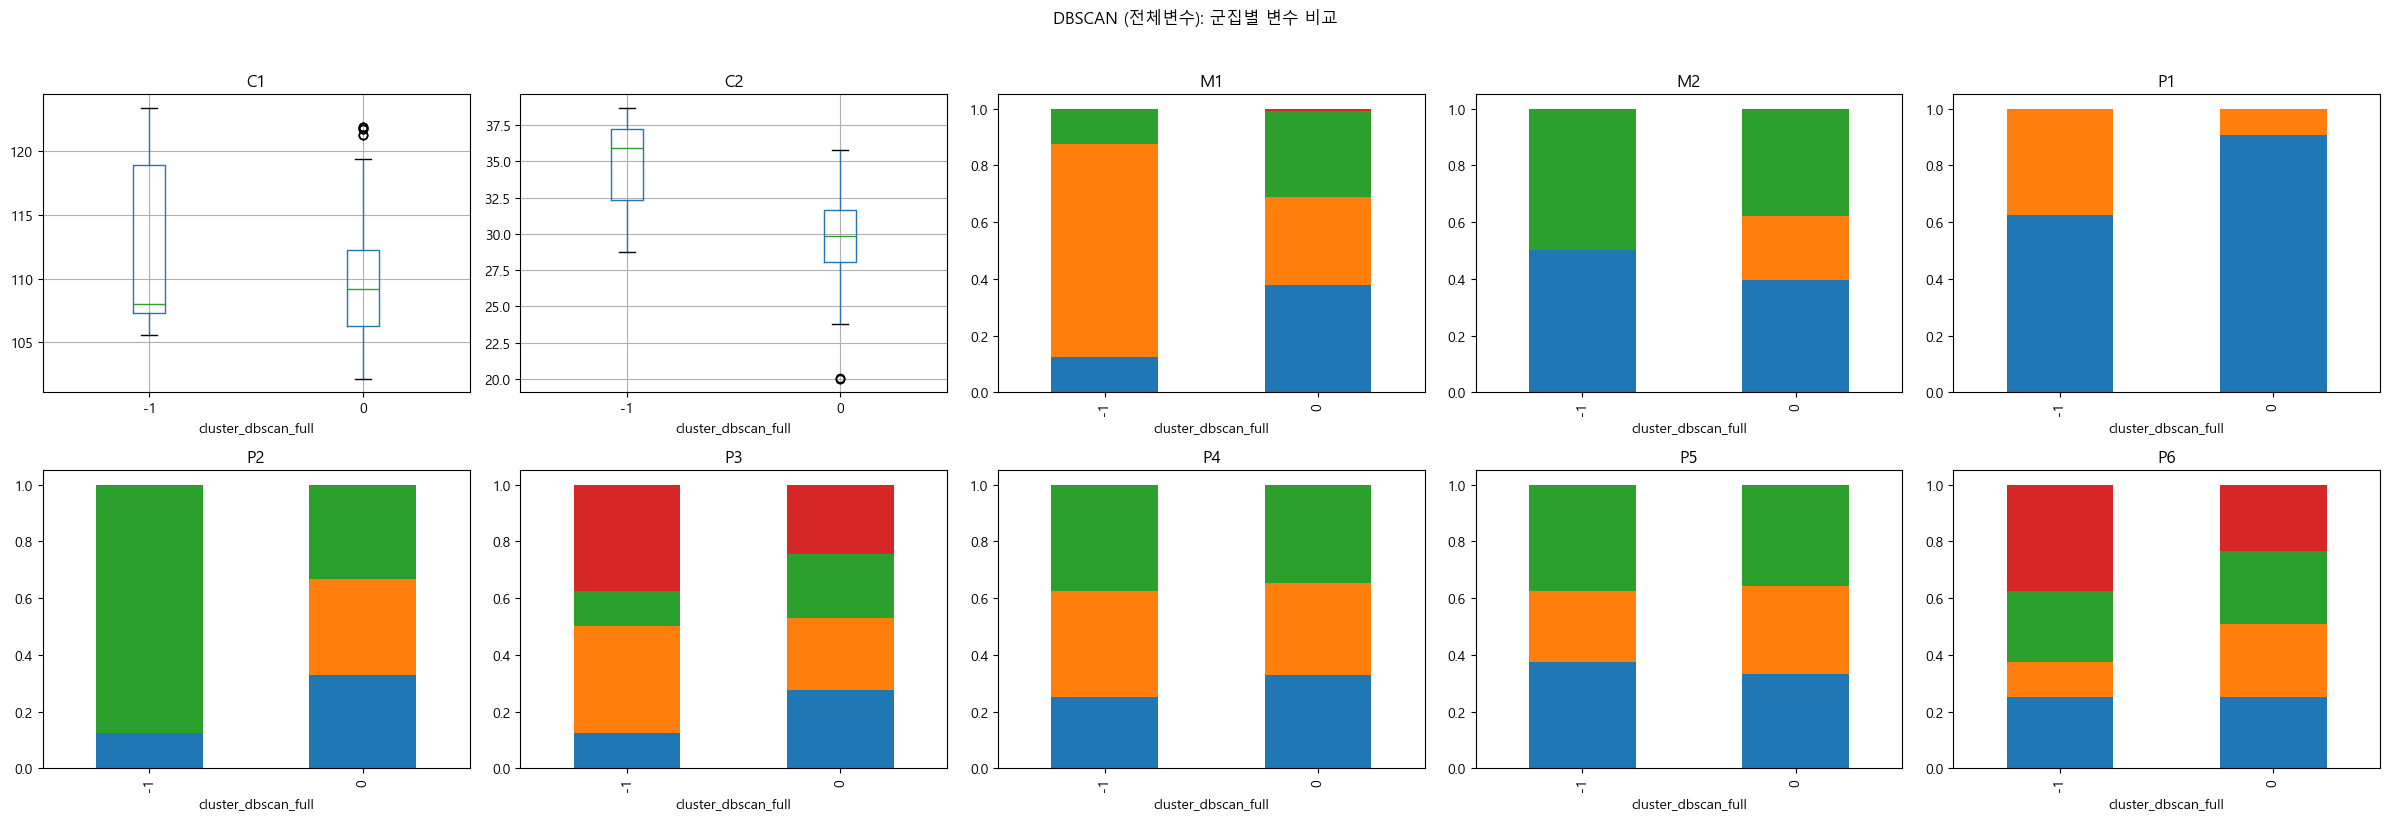

In [30]:
# 2. 군집별 연속형/범주형 변수 값 비교 

# 1) K-Means
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

# 연속형 2개
data.boxplot(column="C1", by="cluster_kmeans_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_kmeans_full", ax=axes[1])
axes[1].set_title("C2")

# 범주형 8개
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_kmeans_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("K-Means (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

# 2) DBSCAN
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

data.boxplot(column="C1", by="cluster_dbscan_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_dbscan_full", ax=axes[1])
axes[1].set_title("C2")

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_dbscan_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("DBSCAN (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

---

## 3) Vibe Coding 실습

K-Means, DBSCAN을 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [31]:
# 필요한 라이브러리 호출하기
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.287160,0,1,-1.175218,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.068195,1,0,-0.263952,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.246088,1,1,-0.368193,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.519980,0,0,-0.756574,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.246088,1,1,0.198407,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


### 3-1) K-Means Clustering

**[과제]**

Silhouette Score로 최적의 군집 수(K)를 확인하고 AI와 함께 K-Means를 학습시켜 보세요. 

이후 군집별로 tenure, MonthlyCharges, Contract 등 주요 변수의 평균/분포를 비교해 각 군집의 특징을 파악하고 고객 세그먼트로서 어떤 이름을 붙일 수 있을지 해석해 보세요.

최적 K: 2 (Silhouette Score: 0.291)


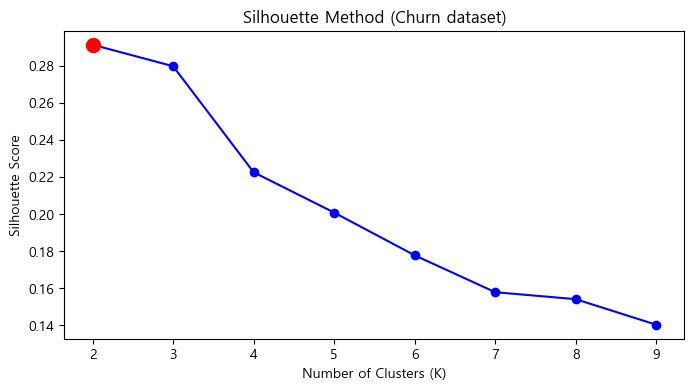


=== 군집별 고객 수 ===
Cluster
0    1526
1    5517
Name: count, dtype: int64

=== 군집별 tenure/MonthlyCharges/TotalCharges 평균 ===


,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,30.45,22.61,668.1
1,32.86,76.47,2728.3



=== 군집별 Contract 비율(%) ===


Contract,Month-to-month,One year,Two year
Cluster,,,
0,34.3,23.9,41.8
1,60.7,20.1,19.2



=== 군집별 실제 Churn 비율 (참고) ===


Cluster
0    0.074
1    0.318
Name: Churn, dtype: float64

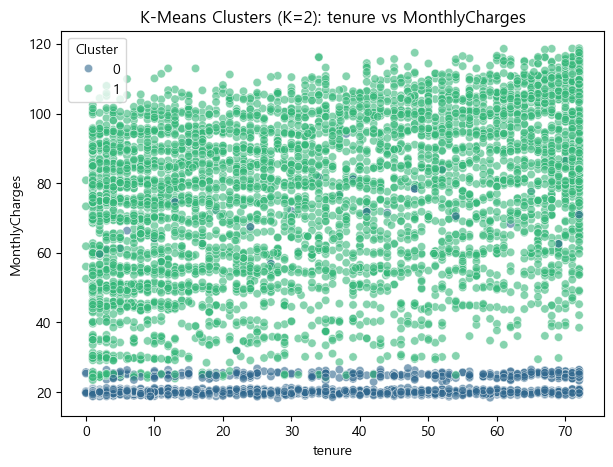


=== 군집 해석용 요약표 ===


,tenure,MonthlyCharges,TotalCharges,Churn_rate
Cluster,,,,
0,30.45,22.61,668.1,0.074
1,32.86,76.47,2728.3,0.318



=== 세그먼트 이름 제안 가이드 (프로파일표 기준으로 직접 매칭) ===
- tenure 낮음 + MonthlyCharges 높음 + Churn_rate 높음 -> "신규 고요금 이탈 위험군"
- tenure 높음 + Contract 장기 비중 높음 + Churn_rate 낮음 -> "장기 충성 고객군"
- tenure 중간 + MonthlyCharges 중간 -> "안정적 일반 고객군"
- 위 cluster_profile / contract_profile / churn_rate_by_cluster 값을 보고
  각 Cluster 번호에 실제 이름을 붙여 해석을 완성하세요.



In [33]:
# [3-1 과제] Silhouette Score로 최적 K 탐색 + K-Means 학습 + 군집 해석

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

# 1) Silhouette Score로 최적 K 탐색
X_arr = X.values if hasattr(X, "values") else X
sil_scores_km = []
K_range_km = range(2, 10)

for k in K_range_km:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels_k = km.fit_predict(X_arr)
    sil_scores_km.append(silhouette_score(X_arr, labels_k))

best_k_km = K_range_km[np.argmax(sil_scores_km)]
print(f"최적 K: {best_k_km} (Silhouette Score: {max(sil_scores_km):.3f})")

plt.figure(figsize=(8, 4))
plt.plot(K_range_km, sil_scores_km, "bo-")
plt.scatter(best_k_km, max(sil_scores_km), c="red", s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (Churn dataset)")
plt.xticks(list(K_range_km))
plt.show()

# 2) 최적 K로 K-Means 학습
kmeans_final = KMeans(n_clusters=best_k_km, random_state=0, n_init=10)
km_labels = kmeans_final.fit_predict(X_arr)

data_km = data.copy()
data_km["Cluster"] = km_labels

print("\n=== 군집별 고객 수 ===")
print(data_km["Cluster"].value_counts().sort_index())

# 3) 군집별 주요 변수 평균/분포 비교
profile_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cluster_profile = data_km.groupby("Cluster")[profile_cols].mean().round(2)

# Contract는 범주형이므로 군집별 비율(%)로 비교
contract_profile = (
    pd.crosstab(data_km["Cluster"], data_km["Contract"], normalize="index")
    .round(3) * 100
)

print("\n=== 군집별 tenure/MonthlyCharges/TotalCharges 평균 ===")
display(cluster_profile)

print("\n=== 군집별 Contract 비율(%) ===")
display(contract_profile)

# Churn 비율도 함께 확인 (해석 참고용, 군집화엔 미사용)
churn_rate_by_cluster = data_km.groupby("Cluster")["Churn"].apply(lambda s: (s == "Yes").mean()).round(3)
print("\n=== 군집별 실제 Churn 비율 (참고) ===")
display(churn_rate_by_cluster)

# 4) 시각화: 군집별 tenure vs MonthlyCharges
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=data_km, x="tenure", y="MonthlyCharges", hue="Cluster", palette="viridis", alpha=0.6
)
plt.title(f"K-Means Clusters (K={best_k_km}): tenure vs MonthlyCharges")
plt.show()

print("\n=== 군집 해석용 요약표 ===")
segment_summary = cluster_profile.join(churn_rate_by_cluster.rename("Churn_rate"))
display(segment_summary)

print("""
=== 세그먼트 이름 제안 가이드 (프로파일표 기준으로 직접 매칭) ===
- tenure 낮음 + MonthlyCharges 높음 + Churn_rate 높음 -> "신규 고요금 이탈 위험군"
- tenure 높음 + Contract 장기 비중 높음 + Churn_rate 낮음 -> "장기 충성 고객군"
- tenure 중간 + MonthlyCharges 중간 -> "안정적 일반 고객군"
- 위 cluster_profile / contract_profile / churn_rate_by_cluster 값을 보고
  각 Cluster 번호에 실제 이름을 붙여 해석을 완성하세요.
""")

### 3-2) DBSCAN 적용

**[과제]** 

AI와 함께 최적의 eps를 찾아 DBSCAN을 학습시켜 보세요.

K-Means와 결과가 어떻게 다른지, Noise로 분류된 고객들은 어떤 특징을 보이는지 확인해 보세요.

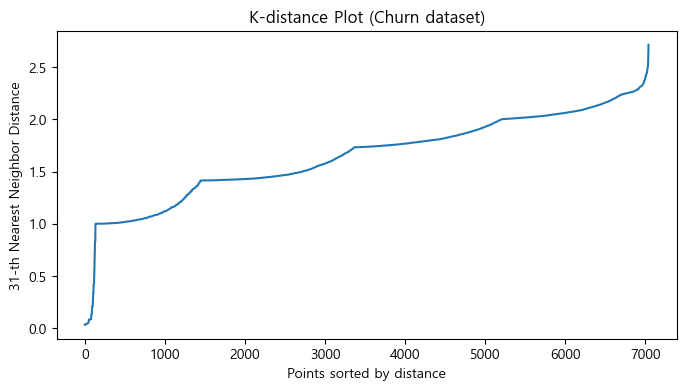

min_samples = 31
위 그래프의 elbow(급격히 꺾이는) 지점의 y값을 eps 후보로 사용합니다.

=== percentile별 eps / 군집수 / 노이즈 비율 ===


,percentile,eps,n_clusters,n_noise,noise_ratio(%)
0,50,1.7364,2,1750,24.85
1,60,1.7882,2,1095,15.55
2,70,1.9066,2,487,6.91
3,75,2.0036,2,250,3.55
4,80,2.0254,2,140,1.99
5,85,2.0587,2,41,0.58
6,90,2.1162,2,17,0.24
7,95,2.2303,2,1,0.01
8,99,2.3337,2,0,0.00



선택된 eps: 2.0254 (percentile=80, 예상 노이즈 비율=1.99%)

=== 최종 DBSCAN 결과 (eps=2.0254, min_samples=31) ===
군집 수: 2, 노이즈 수: 140 (1.99%)

=== K-Means Cluster vs DBSCAN Cluster 교차표 ===


Cluster_DB,-1,0,1
Cluster,,,
0,3,0,1523
1,137,5380,0



=== Noise vs Normal 평균 비교 (tenure/MonthlyCharges/TotalCharges) ===


,Noise_mean,Normal_mean,Diff
tenure,42.51,32.13,10.37
MonthlyCharges,58.65,64.92,-6.27
TotalCharges,2387.59,2279.77,107.81



Noise 그룹 Churn 비율: 0.071
Normal 그룹 Churn 비율: 0.269

=== 해석 가이드 ===
- K-Means는 모든 고객을 반드시 하나의 군집에 배정하지만,
  DBSCAN은 밀도가 낮은 지점을 Noise(-1)로 분리함.
- 교차표를 보면 K-Means의 특정 군집이 DBSCAN에서는 여러 군집+Noise로 쪼개지는지 확인 가능.
- Noise 그룹의 Churn 비율이 Normal보다 높다면,
  '전형적이지 않은 이용 패턴을 가진 고객'이 실제로 이탈 위험도 더 크다는 신호로 해석할 수 있음.



In [34]:
# [3-2 과제] K-distance Plot으로 eps 탐색 + DBSCAN 학습 + K-Means 비교 + Noise 특징 확인

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_arr = X.values if hasattr(X, "values") else X

# 1) min_samples 설정 (차원 수 기반) + K-distance Plot
min_samples_db = X_arr.shape[1] + 1

neighbors = NearestNeighbors(n_neighbors=min_samples_db)
neighbors_fit = neighbors.fit(X_arr)
distances, _ = neighbors_fit.kneighbors(X_arr)
k_distances = np.sort(distances[:, min_samples_db - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_db}-th Nearest Neighbor Distance")
plt.title("K-distance Plot (Churn dataset)")
plt.show()

print(f"min_samples = {min_samples_db}")
print("위 그래프의 elbow(급격히 꺾이는) 지점의 y값을 eps 후보로 사용합니다.")

# 2) eps 후보 비교: percentile 그리드를 스캔하며 군집수/노이즈 비율 관찰
percentile_grid = [50, 60, 70, 75, 80, 85, 90, 95, 99]
scan_rows = []
for p in percentile_grid:
    eps_val = np.percentile(k_distances, p)
    db_tmp = DBSCAN(eps=eps_val, min_samples=min_samples_db)
    labels_tmp = db_tmp.fit_predict(X_arr)
    n_clusters_tmp = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise_tmp = int((labels_tmp == -1).sum())
    scan_rows.append({
        "percentile": p,
        "eps": round(eps_val, 4),
        "n_clusters": n_clusters_tmp,
        "n_noise": n_noise_tmp,
        "noise_ratio(%)": round(n_noise_tmp / len(labels_tmp) * 100, 2),
    })
eps_scan_df = pd.DataFrame(scan_rows)
print("\n=== percentile별 eps / 군집수 / 노이즈 비율 ===")
display(eps_scan_df)

candidate_rows = eps_scan_df[
    (eps_scan_df["n_clusters"] >= 2)
    & (eps_scan_df["noise_ratio(%)"] >= 1)
    & (eps_scan_df["noise_ratio(%)"] <= 5)
]
best_row = candidate_rows.iloc[-1] if len(candidate_rows) > 0 else eps_scan_df.iloc[-1]
best_eps = best_row["eps"]
print(f"\n선택된 eps: {best_eps} (percentile={int(best_row['percentile'])}, "
      f"예상 노이즈 비율={best_row['noise_ratio(%)']}%)")

dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples_db)
db_labels = dbscan_final.fit_predict(X_arr)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print(f"\n=== 최종 DBSCAN 결과 (eps={best_eps:.4f}, min_samples={min_samples_db}) ===")
print(f"군집 수: {n_clusters_db}, 노이즈 수: {n_noise_db} ({n_noise_db/len(db_labels)*100:.2f}%)")

data_db = data.copy()
data_db["Cluster_DB"] = db_labels

# 4) K-Means 결과와 비교 (직전 3-1 셀 결과 재사용)
if "data_km" in globals():
    compare_df = data_km[["Cluster"]].copy()
    compare_df["Cluster_DB"] = db_labels
    cross_tab = pd.crosstab(compare_df["Cluster"], compare_df["Cluster_DB"])
    print("\n=== K-Means Cluster vs DBSCAN Cluster 교차표 ===")
    display(cross_tab)
else:
    print("\n(참고) K-Means 결과(data_km)가 없어 교차비교는 생략합니다. 3-1 셀을 먼저 실행하세요.")

# 5) Noise로 분류된 고객 특징 확인
noise_mask = db_labels == -1
noise_df = data_db.loc[noise_mask]
normal_df = data_db.loc[~noise_mask]

profile_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
noise_compare = pd.DataFrame({
    "Noise_mean": noise_df[profile_cols].mean(),
    "Normal_mean": normal_df[profile_cols].mean(),
})
noise_compare["Diff"] = noise_compare["Noise_mean"] - noise_compare["Normal_mean"]

print("\n=== Noise vs Normal 평균 비교 (tenure/MonthlyCharges/TotalCharges) ===")
display(noise_compare.round(2))

noise_churn_rate = (noise_df["Churn"] == "Yes").mean() if len(noise_df) else np.nan
normal_churn_rate = (normal_df["Churn"] == "Yes").mean() if len(normal_df) else np.nan

print(f"\nNoise 그룹 Churn 비율: {noise_churn_rate:.3f}")
print(f"Normal 그룹 Churn 비율: {normal_churn_rate:.3f}")

print("""
=== 해석 가이드 ===
- K-Means는 모든 고객을 반드시 하나의 군집에 배정하지만,
  DBSCAN은 밀도가 낮은 지점을 Noise(-1)로 분리함.
- 교차표를 보면 K-Means의 특정 군집이 DBSCAN에서는 여러 군집+Noise로 쪼개지는지 확인 가능.
- Noise 그룹의 Churn 비율이 Normal보다 높다면,
  '전형적이지 않은 이용 패턴을 가진 고객'이 실제로 이탈 위험도 더 크다는 신호로 해석할 수 있음.
""")